In [1]:
%matplotlib inline

In [78]:
import os
from pathlib import Path

import numpy as np
import scipy as sp
import matplotlib as mpl
import matplotlib.pyplot as plt

plt.rc('figure', figsize=(6, 4.5))
mpl.rcParams['font.size'] = 10
mpl.rcParams['figure.dpi'] = 150
mpl.rcParams['figure.facecolor'] = 'w'
mpl.rcParams['hatch.linewidth'] = 0.5
mpl.rcParams['hatch.color'] = '0.25'

import xarray as xr
import xgcm

from scipy.special import erf
from numpy import pi as π

In [79]:
# trig functions that take degrees

def sind(x):
    return np.sin(np.deg2rad(x))

def cosd(x):
    return np.cos(np.deg2rad(x))

# Make input directory

In [50]:
Path('./INPUT').mkdir(exist_ok=True)

# Load grid

In [51]:
coord_map_h = {'lath': 'yh', 'latq': 'yq', 'lonh': 'xh', 'lonq': 'xq'}
coord_map_v = {'Interface': 'zi', 'Layer': 'zl'}

In [57]:
ds = xr.open_dataset('ocean_geometry.nc')
grid = ds.rename(coord_map_h)
ds.close() # leaving these open seems to confuse MOM6
grid

<xarray.Dataset>
Dimensions:  (xh: 60, xq: 61, yh: 100, yq: 101)
Coordinates:
  * yh       (yh) float64 10.25 10.75 11.25 11.75 ... 58.25 58.75 59.25 59.75
  * xh       (xh) float64 0.25 0.75 1.25 1.75 2.25 ... 28.25 28.75 29.25 29.75
  * yq       (yq) float64 10.0 10.5 11.0 11.5 12.0 ... 58.0 58.5 59.0 59.5 60.0
  * xq       (xq) float64 0.0 0.5 1.0 1.5 2.0 2.5 ... 28.0 28.5 29.0 29.5 30.0
Data variables: (12/19)
    geolatb  (yq, xq) float64 ...
    geolonb  (yq, xq) float64 ...
    geolat   (yh, xh) float64 ...
    geolon   (yh, xh) float64 ...
    D        (yh, xh) float64 ...
    f        (yq, xq) float64 ...
    ...       ...
    dyBu     (yq, xq) float64 ...
    Ah       (yh, xh) float64 ...
    Aq       (yq, xq) float64 ...
    dxCvo    (yq, xh) float64 ...
    dyCuo    (yh, xq) float64 ...
    wet      (yh, xh) float64 ...
Attributes:
    filename:  ./ocean_geometry.nc

In [58]:
ds = xr.open_dataset('MOM_IC.nc')
ic = ds.squeeze().rename({**coord_map_h, **coord_map_v})
ds.close()

In [59]:
# add the vertical coordinates into the grid descriptor
grid['zi'] = ic.zi
grid['zl'] = ic.zl
grid

<xarray.Dataset>
Dimensions:  (xh: 60, xq: 61, yh: 100, yq: 101, zi: 3, zl: 2)
Coordinates:
  * yh       (yh) float64 10.25 10.75 11.25 11.75 ... 58.25 58.75 59.25 59.75
  * xh       (xh) float64 0.25 0.75 1.25 1.75 2.25 ... 28.25 28.75 29.25 29.75
  * yq       (yq) float64 10.0 10.5 11.0 11.5 12.0 ... 58.0 58.5 59.0 59.5 60.0
  * xq       (xq) float64 0.0 0.5 1.0 1.5 2.0 2.5 ... 28.0 28.5 29.0 29.5 30.0
    Time     timedelta64[ns] 00:00:00
  * zi       (zi) float64 1.034e+03 1.036e+03 1.037e+03
  * zl       (zl) float64 1.035e+03 1.036e+03
Data variables: (12/19)
    geolatb  (yq, xq) float64 10.0 10.0 10.0 10.0 10.0 ... 60.0 60.0 60.0 60.0
    geolonb  (yq, xq) float64 0.0 0.5 1.0 1.5 2.0 ... 28.0 28.5 29.0 29.5 30.0
    geolat   (yh, xh) float64 10.25 10.25 10.25 10.25 ... 59.75 59.75 59.75
    geolon   (yh, xh) float64 0.25 0.75 1.25 1.75 ... 28.25 28.75 29.25 29.75
    D        (yh, xh) float64 2e+03 2e+03 2e+03 2e+03 ... 2e+03 2e+03 2e+03
    f        (yq, xq) float64 2.533e-05 2.533e-05 ... 0.0001263 0.0001263
    ...       ...
    dyBu     (yq, xq) float64 5.566e+04 5.566e+04 ... 5.566e+04 5.566e+04
    Ah       (yh, xh) float64 3.048e+09 3.048e+09 ... 1.561e+09 1.561e+09
    Aq       (yq, xq) float64 3.051e+09 3.051e+09 ... 1.549e+09 1.549e+09
    dxCvo    (yq, xh) float64 0.0 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    dyCuo    (yh, xq) float64 0.0 5.566e+04 5.566e+04 ... 5.566e+04 0.0
    wet      (yh, xh) float64 1.0 1.0 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0 1.0
Attributes:
    filename:  ./ocean_geometry.nc

In [60]:
grid_op = xgcm.Grid(grid, coords={
    'X': {'center': 'xh', 'outer': 'xq'},
    'Y': {'center': 'yh', 'outer': 'yq'},
    'Z': {'inner': 'zl', 'outer': 'zi'},

})
grid_op

<xgcm.Grid>
X Axis (periodic, boundary=None):
  * center   xh --> outer
  * outer    xq --> center
Y Axis (periodic, boundary=None):
  * center   yh --> outer
  * outer    yq --> center
Z Axis (periodic, boundary=None):
  * inner    zl
  * outer    zi

# Layer configuration

In [4]:
# number of layers
NK = 2

# maximum depth

# interface depths
eta = np.array([
       0,
    -750,
  -12000, # the last entry can be anything as long as it's deeper than the basin
], dtype=float) 

interface_IC = xr.Dataset(
    {'eta': (['nki'], eta, {'long_name': 'Initial depth of interfaces', 'units': 'meters'})},
)

interface_IC.to_netcdf('INPUT/interface_IC.nc')

In [5]:
interface_IC

<xarray.Dataset>
Dimensions:  (nki: 3)
Dimensions without coordinates: nki
Data variables:
    eta      (nki) float64 0.0 -750.0 -1.2e+04

# Topography - Erf-like shelves on eastern and western boundaries

## Case I: constant width in degrees

In [72]:
λe = 30 # longitude of eastern boundary

Hshelf = 100 # shelf depth
Hmax = 4000

Lshelf = 1.5 # shelf width in degrees
Lslope = 1.5 # slope width in degrees

def H0(λ):
    return Hshelf + 0.5*(Hmax - Hshelf)*(1 + erf(np.sqrt(π)*((λ - Lshelf)/Lslope - 0.5)))

H = H0(grid.geolon) + H0(λe - grid.geolon) - Hmax

In [84]:
topog = xr.Dataset()

# copy over coordinates
topog['yh'] = grid.yh
topog['xh'] = grid.xh

topog['depth'] = (['yh', 'xh'], H, {'long_name': 'Ocean Depth', 'units': 'm'})

topog.to_netcdf('INPUT/topog_degrees.nc')

topog

<xarray.Dataset>
Dimensions:  (xh: 60, yh: 100)
Coordinates:
    Time     timedelta64[ns] 00:00:00
  * yh       (yh) float64 10.25 10.75 11.25 11.75 ... 58.25 58.75 59.25 59.75
  * xh       (xh) float64 0.25 0.75 1.25 1.75 2.25 ... 28.25 28.75 29.25 29.75
Data variables:
    depth    (yh, xh) float64 101.6 123.8 284.7 886.7 ... 284.7 123.8 101.6

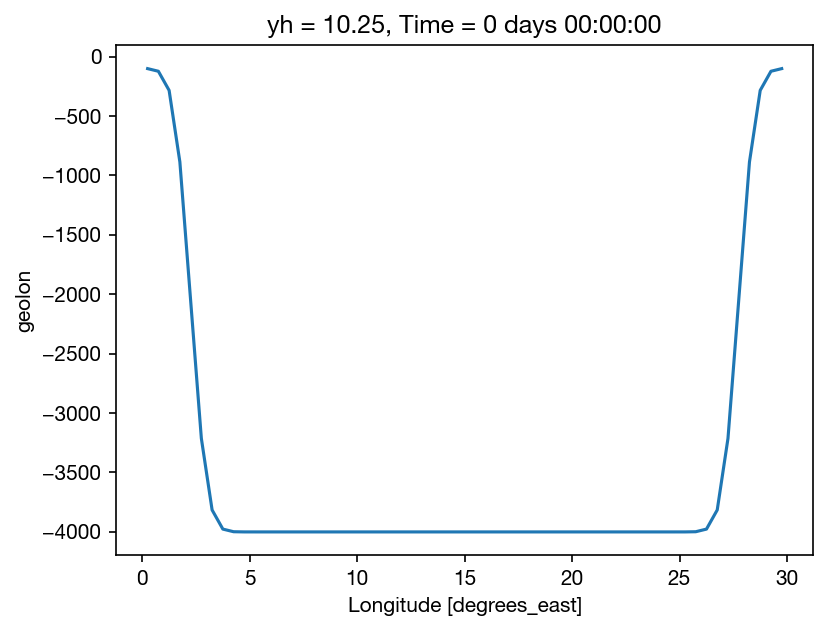

In [75]:
(-H).isel(yh=0).plot()

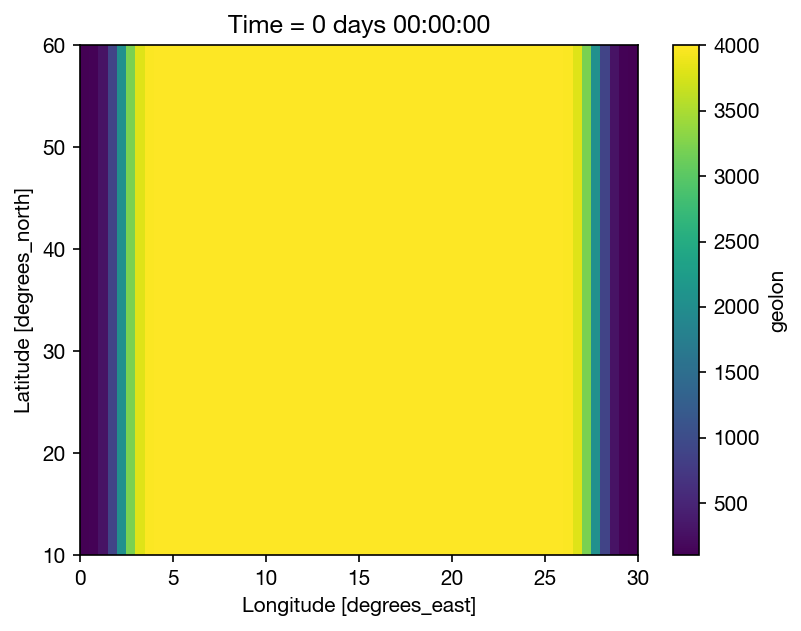

In [74]:
H.plot()

# Wind forcing

In [11]:
τ0 = 0.1

θs = 15
θn = 60
θ0 = 30

In [82]:
taux = np.zeros((NY, NX+1))
tauy = np.zeros((NY+1, NX))
idx = (grid.yh >= θs).values
idx0 = np.nonzero(idx)[0][0]
taux[idx,:] = (τ0*sind(6*(grid.yh[idx].values - θ0)))[:,np.newaxis]
taux[~idx,:] = -τ0
# taux[~idx,:] = taux[idx0,:]

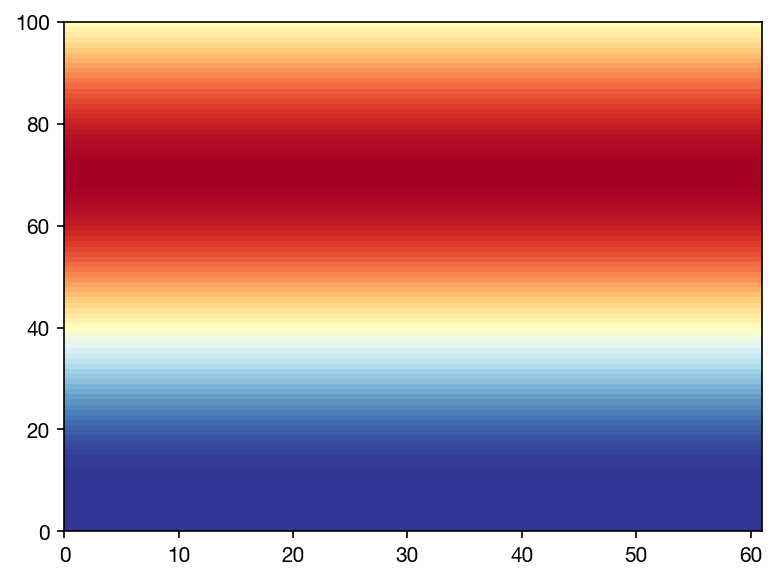

In [81]:
plt.pcolormesh(taux)

In [83]:
forcing = xr.Dataset()

# copy over coordinates - MOM6 expects xq and yq to have be missing the last point
forcing['yh'] = grid.yh
forcing['yq'] = grid.yq[:-1]
forcing['xh'] = grid.xh
forcing['xq'] = grid.xq[:-1]

forcing['STRESS_X'] = (['yh', 'xq'], taux[:,:-1], {'long_name': 'Zonal Momentum Flux', 'units': 'Pa'})
forcing['STRESS_Y'] = (['yq', 'xh'], tauy[:-1,:], {'long_name': 'Meridional Momentum Flux', 'units': 'Pa'})

forcing.to_netcdf('INPUT/forcing.nc')

forcing

<xarray.Dataset>
Dimensions:   (xh: 60, xq: 60, yh: 100, yq: 100)
Coordinates:
    Time      timedelta64[ns] 00:00:00
  * yh        (yh) float64 10.25 10.75 11.25 11.75 ... 58.25 58.75 59.25 59.75
  * yq        (yq) float64 10.0 10.5 11.0 11.5 12.0 ... 57.5 58.0 58.5 59.0 59.5
  * xh        (xh) float64 0.25 0.75 1.25 1.75 2.25 ... 28.25 28.75 29.25 29.75
  * xq        (xq) float64 0.0 0.5 1.0 1.5 2.0 2.5 ... 27.5 28.0 28.5 29.0 29.5
Data variables:
    STRESS_X  (yh, xq) float64 -0.1 -0.1 -0.1 ... 0.002618 0.002618 0.002618
    STRESS_Y  (yq, xh) float64 0.0 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0

Read back in after running the model to make sure it took

In [21]:
ds = xr.open_dataset('forcing__0001_003.nc')
forcing_diag = ds
ds.close()

<xarray.Dataset>
Dimensions:     (Time: 2, nv: 2, xq: 61, yh: 100)
Coordinates:
  * xq          (xq) float64 0.0 0.5 1.0 1.5 2.0 ... 28.0 28.5 29.0 29.5 30.0
  * yh          (yh) float64 10.25 10.75 11.25 11.75 ... 58.25 58.75 59.25 59.75
  * Time        (Time) object 0001-01-03 12:00:00 0001-01-08 12:00:00
  * nv          (nv) float64 1.0 2.0
Data variables:
    taux        (Time, yh, xq) float32 ...
    average_T1  (Time) object ...
    average_T2  (Time) object ...
    average_DT  (Time) timedelta64[ns] ...
    Time_bnds   (Time, nv) timedelta64[ns] ...
Attributes:
    NumFilesInSet:  1
    title:          MOM Experiment
    grid_type:      regular
    grid_tile:      N/A

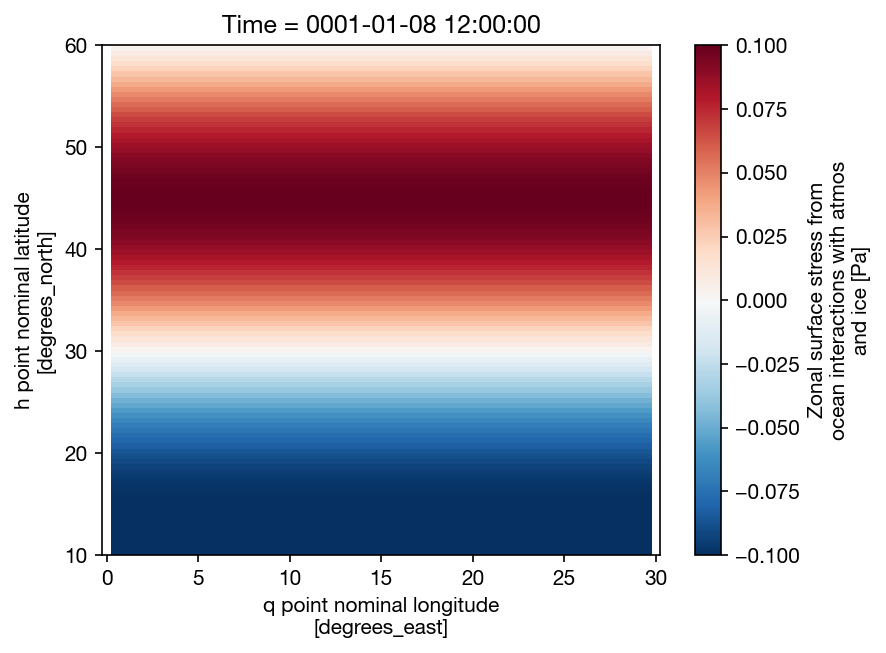

In [23]:
forcing_diag.taux.isel(Time=-1).plot()